In [60]:
import time
import pandas as pd
import numpy as np
from pathlib import Path
import os
import tkinter
import matplotlib
from matplotlib.backends.backend_tkagg import *

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def select_scenario() -> Path:
    # Get all folder names from the logs folder
    logs_folder = Path(os.path.abspath('')) / 'logs'
    scenarios = [folder for folder in logs_folder.iterdir() if folder.is_dir()]
    print('Select a scenario:')
    for i, folder in enumerate(scenarios):
        print(f"[{i}]: {folder.name}")
    scenario_selection = int(input("Input which scenario you want to visualize: "))
    runs_folder = scenarios[scenario_selection]
    print(f"Selected scenario: {runs_folder.name}")
    print()
    time.sleep(1)
    print("Select a test run:")
    runs = [folder for folder in runs_folder.iterdir() if folder.is_dir()]
    for i, folder in enumerate(runs):
        print(f"[{i}]: {folder.name}")
    run_selection = int(input("Input which run you want to visualise: "))
    print(f"Selected run: {runs[run_selection].name}")
    return runs[run_selection]

scenario_folder = select_scenario()

Select a scenario:
[0]: lake
[1]: soil
Selected scenario: lake

Select a test run:
[0]: 2025-02-22_17:18
[1]: 2025-02-22_17:10
[2]: 2025-02-22_16:33
[3]: 2025-02-22_17:11
[4]: 2025-02-22_16:32
[5]: 2025-02-22_16:29
[6]: 2025-02-22_16:39
[7]: 2025-02-22_16:28
[8]: 2025-02-22_17:07
[9]: 2025-02-22_16:34
[10]: 2025-02-22_17:09
[11]: 2025-02-22_17:12
[12]: 2025-02-22_17:06
[13]: 2025-02-22_16:31
[14]: 2025-02-22_17:20
[15]: 2025-02-22_17:16
[16]: 2025-02-22_16:30
Selected run: 2025-02-22_16:28


In [62]:
def node_to_node_distance(x1,y1,z1,x2,y2,z2):
    return ((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)**0.5

node_pos_df = pd.read_csv(scenario_folder / 'CourseChange.csv', delimiter=';', index_col=False)
node_pos_df["Time"] = node_pos_df["Time"].str.replace('ns', '').astype(float)
node_pos_df.drop_duplicates(subset=["Time","NodeId"], keep='last', inplace=True)
node_pos_df.reset_index(drop=True, inplace=True)
node_pos_df

,Time,NodeType,NodeId,X,Y,Z
0,0.0,STA,0,0.05,0.05,-0.1
1,0.0,STA,1,0.15,0.05,-0.1
2,0.0,STA,2,0.25,0.05,-0.1
3,0.0,STA,3,0.35,0.05,-0.1
4,0.0,STA,4,0.45,0.05,-0.1
5,0.0,STA,5,0.55,0.05,-0.1
6,0.0,STA,6,0.65,0.05,-0.1
7,0.0,STA,7,0.75,0.05,-0.1
8,0.0,STA,8,0.85,0.05,-0.1
9,0.0,STA,9,0.95,0.05,-0.1


In [63]:
rx_packets_df = pd.read_csv(scenario_folder / 'MonitorSnifferRx.csv', delimiter=';', index_col=False)
rx_packets_df["Time"] = rx_packets_df["Time"].str.replace('ns', '').astype(float)
rx_packets_df = rx_packets_df[rx_packets_df["DestinationNodeId"] != "?"]
rx_packets_df = rx_packets_df[rx_packets_df["SourceNodeId"] != "?"]
rx_packets_df["DestinationNodeId"] = rx_packets_df["DestinationNodeId"].astype(int)
rx_packets_df["SourceNodeId"] = rx_packets_df["SourceNodeId"].astype(int)
rx_packets_df["RxNodeId"] = rx_packets_df["RxNodeId"].astype(int)
rx_packets_df = rx_packets_df[rx_packets_df["RxNodeId"] == rx_packets_df["DestinationNodeId"]]
rx_packets_df

/tmp/ipykernel_1509278/1738389641.py:1: DtypeWarning: Columns (7,9,13) have mixed types. Specify dtype option on import or set low_memory=False.
  rx_packets_df = pd.read_csv(scenario_folder / 'MonitorSnifferRx.csv', delimiter=';', index_col=False)


,Time,RxNodeId,PacketId,PacketSize,ReceiverMac,ReceiverNodeId,TransmitterMac,TransmitterNodeId,BSSID,BSSIDNodeId,...,IsShortPreamble,Mode,Retries,Ness,Nss,IsShortGuardInterval,IsStbc,TxPowerLevel,NoiseDbm,SignalDbm
280,5.069460e+08,50,18,102,00:00:00:00:00:33,50,00:00:00:00:00:14,19,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.945,15.7839
397,5.094501e+08,19,20,75,00:00:00:00:00:14,19,00:00:00:00:00:33,50,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-113.976,31.7839
480,5.122061e+08,50,7,102,00:00:00:00:00:33,50,00:00:00:00:00:1b,26,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.945,16.3524
634,5.204621e+08,50,15,102,00:00:00:00:00:33,50,00:00:00:00:00:02,1,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.947,15.7839
730,5.232701e+08,50,17,102,00:00:00:00:00:33,50,00:00:00:00:00:0b,10,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,1,0,1,False,False,0,-113.947,15.7839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707540,2.822765e+12,47,28397,90,00:00:00:00:00:30,47,00:00:00:00:00:33,50,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-114.078,32.4246
722142,2.882590e+12,50,28987,103,00:00:00:00:00:33,50,00:00:00:00:00:31,48,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-113.915,16.2280
722194,2.882772e+12,48,28988,90,00:00:00:00:00:31,48,00:00:00:00:00:33,50,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-114.078,32.2280
736767,2.942567e+12,50,29577,103,00:00:00:00:00:33,50,00:00:00:00:00:32,49,00:00:00:00:00:33,50,...,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0,-113.915,16.0258


In [64]:
tx_packets_df = pd.read_csv(scenario_folder / 'MonitorSnifferTx.csv', delimiter=';', index_col=False)
tx_packets_df["Time"] = tx_packets_df["Time"].str.replace('ns', '').astype(float)
tx_packets_df = tx_packets_df[tx_packets_df["DestinationNodeId"] != "?"]
tx_packets_df = tx_packets_df[tx_packets_df["SourceNodeId"] != "?"]
tx_packets_df["DestinationNodeId"] = tx_packets_df["DestinationNodeId"].astype(int)
tx_packets_df["SourceNodeId"] = tx_packets_df["SourceNodeId"].astype(int)
tx_packets_df["TxNodeId"] = tx_packets_df["TxNodeId"].astype(int)
tx_packets_df = tx_packets_df[tx_packets_df["TxNodeId"] == tx_packets_df["SourceNodeId"]]
tx_packets_df

/tmp/ipykernel_1509278/3543629279.py:1: DtypeWarning: Columns (7,9,13) have mixed types. Specify dtype option on import or set low_memory=False.
  tx_packets_df = pd.read_csv(scenario_folder / 'MonitorSnifferTx.csv', delimiter=';', index_col=False)


,Time,TxNodeId,PacketId,PacketSize,ReceiverMac,ReceiverNodeId,TransmitterMac,TransmitterNodeId,BSSID,BSSIDNodeId,...,ChannelNumber,Rate,IsShortPreamble,Mode,Retries,Ness,Nss,IsShortGuardInterval,IsStbc,TxPowerLevel
5,5.027320e+08,44,5,102,00:00:00:00:00:33,50,00:00:00:00:00:2d,44,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0
6,5.027320e+08,35,6,102,00:00:00:00:00:33,50,00:00:00:00:00:24,35,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0
7,5.027320e+08,26,7,102,00:00:00:00:00:33,50,00:00:00:00:00:1b,26,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0
8,5.027320e+08,38,8,102,00:00:00:00:00:33,50,00:00:00:00:00:27,38,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0
9,5.027320e+08,5,9,102,00:00:00:00:00:33,50,00:00:00:00:00:06,5,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28594,2.822764e+12,50,28397,90,00:00:00:00:00:30,47,00:00:00:00:00:33,50,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0
29180,2.882588e+12,48,28987,103,00:00:00:00:00:33,50,00:00:00:00:00:31,48,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0
29184,2.882770e+12,50,28988,90,00:00:00:00:00:31,48,00:00:00:00:00:33,50,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0
29769,2.942566e+12,49,29577,103,00:00:00:00:00:33,50,00:00:00:00:00:32,49,00:00:00:00:00:33,50,...,1,131,False,OfdmRate1_2MbpsBW1MHz,0,0,1,False,False,0


In [65]:
packet_stats_df = pd.DataFrame()
packet_stats_df['Sent packet count'] = tx_packets_df['PacketId'].value_counts()
packet_stats_df['Received packet count'] = rx_packets_df['PacketId'].value_counts()
packet_stats_df['Dropped packet count'] = packet_stats_df['Sent packet count'] - packet_stats_df['Received packet count']
packet_stats_df['First seen at'] = tx_packets_df.groupby('PacketId')['Time'].min()
packet_stats_df['Received at'] = rx_packets_df.groupby('PacketId')['Time'].max()
packet_stats_df['Latency'] = packet_stats_df['Received at'] - packet_stats_df['First seen at']
packet_stats_df['SourceNodeId'] = tx_packets_df.groupby('PacketId')['SourceNodeId'].first()
packet_stats_df['DestinationNodeId'] = tx_packets_df.groupby('PacketId')['DestinationNodeId'].first()

# Calculate the distance between the two nodes at the time of the most recent position update at the time of the first packet transmission
packet_stats_df['Distance'] = packet_stats_df.apply(lambda row: node_to_node_distance(
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['SourceNodeId'])].iloc[-1]['X'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['SourceNodeId'])].iloc[-1]['Y'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['SourceNodeId'])].iloc[-1]['Z'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['DestinationNodeId'])].iloc[-1]['X'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['DestinationNodeId'])].iloc[-1]['Y'],
    node_pos_df[(node_pos_df['Time'] <= row['First seen at']) & (node_pos_df['NodeId'] == row['DestinationNodeId'])].iloc[-1]['Z'],
), axis=1)

packet_stats_df.tail(50)

,Sent packet count,Received packet count,Dropped packet count,First seen at,Received at,Latency,SourceNodeId,DestinationNodeId,Distance
PacketId,,,,,,,,,
572,1,1,0,5.766468e+09,5.767668e+09,1200010.0,14,50,0.367423
518,1,1,0,5.769456e+09,5.770656e+09,1200010.0,50,48,0.367423
576,1,1,0,5.772132e+09,5.773332e+09,1200010.0,48,50,0.367423
520,1,1,0,5.775328e+09,5.776528e+09,1200010.0,50,27,0.367423
579,1,1,0,5.778004e+09,5.779204e+09,1200010.0,27,50,0.367423
582,1,1,0,5.783408e+09,5.784608e+09,1200005.0,43,50,0.187083
434,1,1,0,3.111272e+09,3.112472e+09,1200013.0,50,49,0.463681
524,1,1,0,5.786396e+09,5.787596e+09,1200011.0,50,16,0.393700
585,1,1,0,5.789072e+09,5.790272e+09,1200011.0,16,50,0.393700


In [66]:
node_statistics_df = pd.DataFrame()
node_statistics_df['NodeId'] = node_pos_df['NodeId'].unique()
node_statistics_df.set_index('NodeId', inplace=True)
node_statistics_df['NodeType'] = node_pos_df.groupby('NodeId')['NodeType'].first()
node_statistics_df['X'] = node_pos_df.groupby('NodeId')['X'].last()
node_statistics_df['Y'] = node_pos_df.groupby('NodeId')['Y'].last()
node_statistics_df['Z'] = node_pos_df.groupby('NodeId')['Z'].last()
node_statistics_df['Sent packet count'] = packet_stats_df.groupby('SourceNodeId')['Sent packet count'].sum()
node_statistics_df['Received packet count'] = packet_stats_df.groupby('DestinationNodeId')['Received packet count'].sum()
node_statistics_df['Dropped packet count'] = packet_stats_df.groupby('SourceNodeId')['Dropped packet count'].sum()
node_statistics_df['Average latency'] = packet_stats_df.groupby('SourceNodeId')['Latency'].mean()
node_statistics_df['Average signal strength'] = rx_packets_df.groupby('DestinationNodeId')['SignalDbm'].mean()
node_statistics_df

,NodeType,X,Y,Z,Sent packet count,Received packet count,Dropped packet count,Average latency,Average signal strength
NodeId,,,,,,,,,
0,STA,0.05,0.05,-0.1,12,3,7,7.910723e+07,31.646500
1,STA,0.15,0.05,-0.1,7,3,3,2.990515e+07,31.783900
2,STA,0.25,0.05,-0.1,12,3,7,7.751317e+07,31.898200
3,STA,0.35,0.05,-0.1,10,3,5,3.536780e+07,31.981500
4,STA,0.45,0.05,-0.1,11,3,7,1.280943e+08,32.025800
5,STA,0.55,0.05,-0.1,9,3,5,1.083403e+08,32.025800
6,STA,0.65,0.05,-0.1,7,3,3,1.469758e+07,31.981500
7,STA,0.75,0.05,-0.1,11,3,7,8.883018e+07,31.898200
8,STA,0.85,0.05,-0.1,11,3,6,7.915680e+07,31.783900


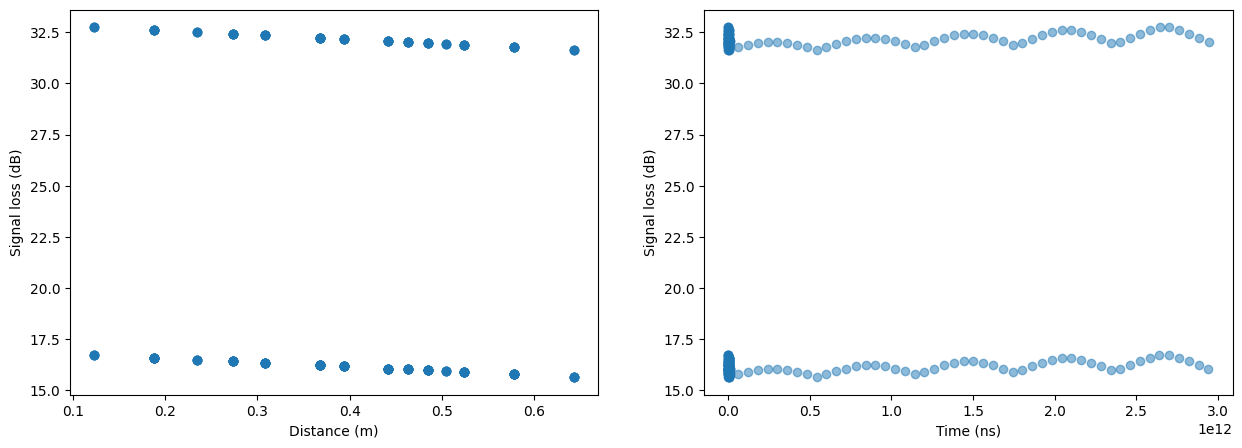

In [67]:
# Merge packet_stats_df with rx_packets_df based on PacketId
merged_df = pd.merge(packet_stats_df, rx_packets_df, on='PacketId', how='inner')

%matplotlib inline
# Plot signal loss over distance and time
fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].scatter(merged_df['Distance'], merged_df['SignalDbm'], alpha=0.5)
ax[0].set_xlabel('Distance (m)')
ax[0].set_ylabel('Signal loss (dB)')
ax[1].scatter(merged_df['Time'], merged_df['SignalDbm'], alpha=0.5)
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Signal loss (dB)')
plt.show()

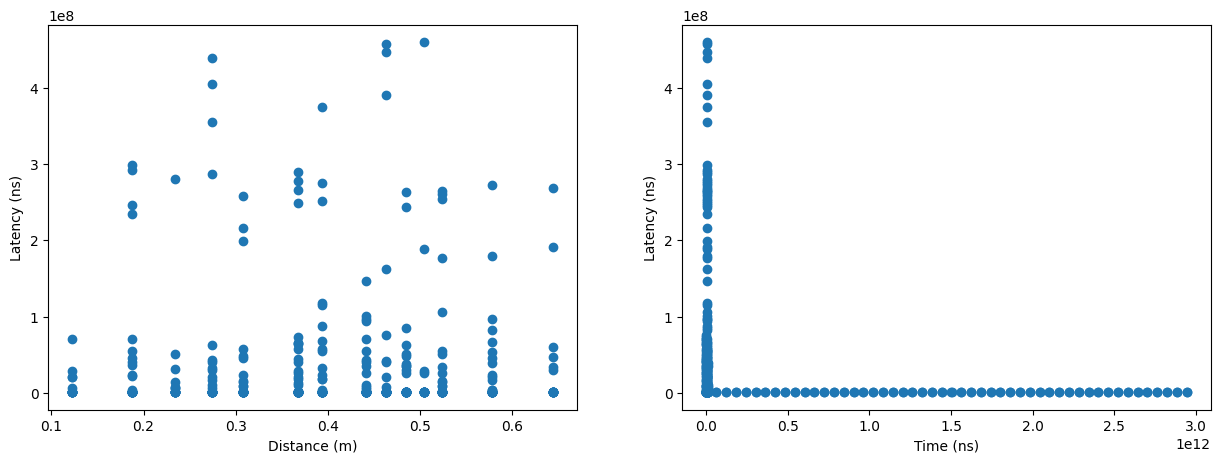

In [68]:
%matplotlib inline
# Plot latency over distance in one plot, and over time in another
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].scatter(packet_stats_df['Distance'], packet_stats_df['Latency'])
ax[0].set_xlabel('Distance (m)')
ax[0].set_ylabel('Latency (ns)')
ax[1].scatter(packet_stats_df['First seen at'], packet_stats_df['Latency'])
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Latency (ns)')
plt.show()

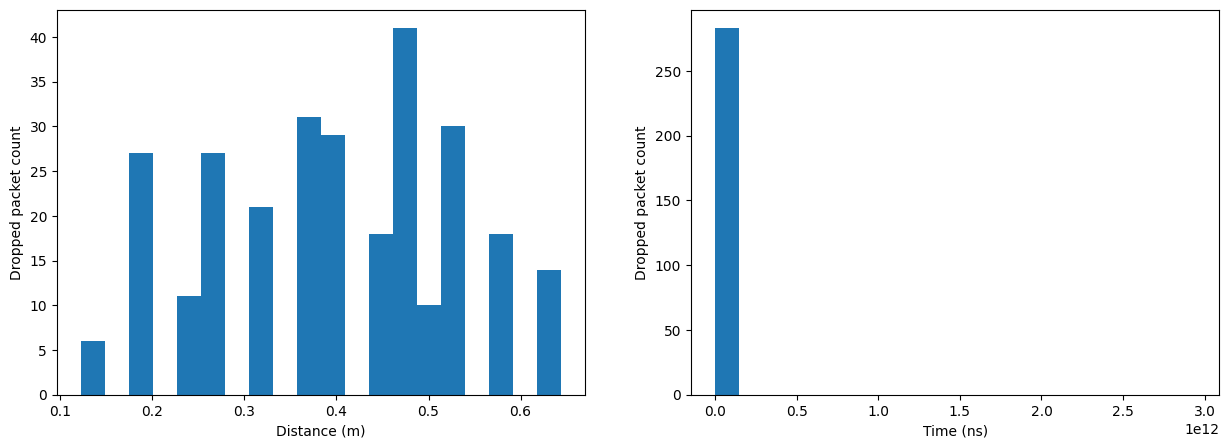

In [69]:
%matplotlib inline
# Plot dropped packets over distance and time
fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].hist(packet_stats_df['Distance'], weights=packet_stats_df['Dropped packet count'], bins=20)
ax[0].set_xlabel('Distance (m)')
ax[0].set_ylabel('Dropped packet count')
ax[1].hist(packet_stats_df['First seen at'], weights=packet_stats_df['Dropped packet count'], bins=20)
ax[1].set_xlabel('Time (ns)')
ax[1].set_ylabel('Dropped packet count')
plt.show()


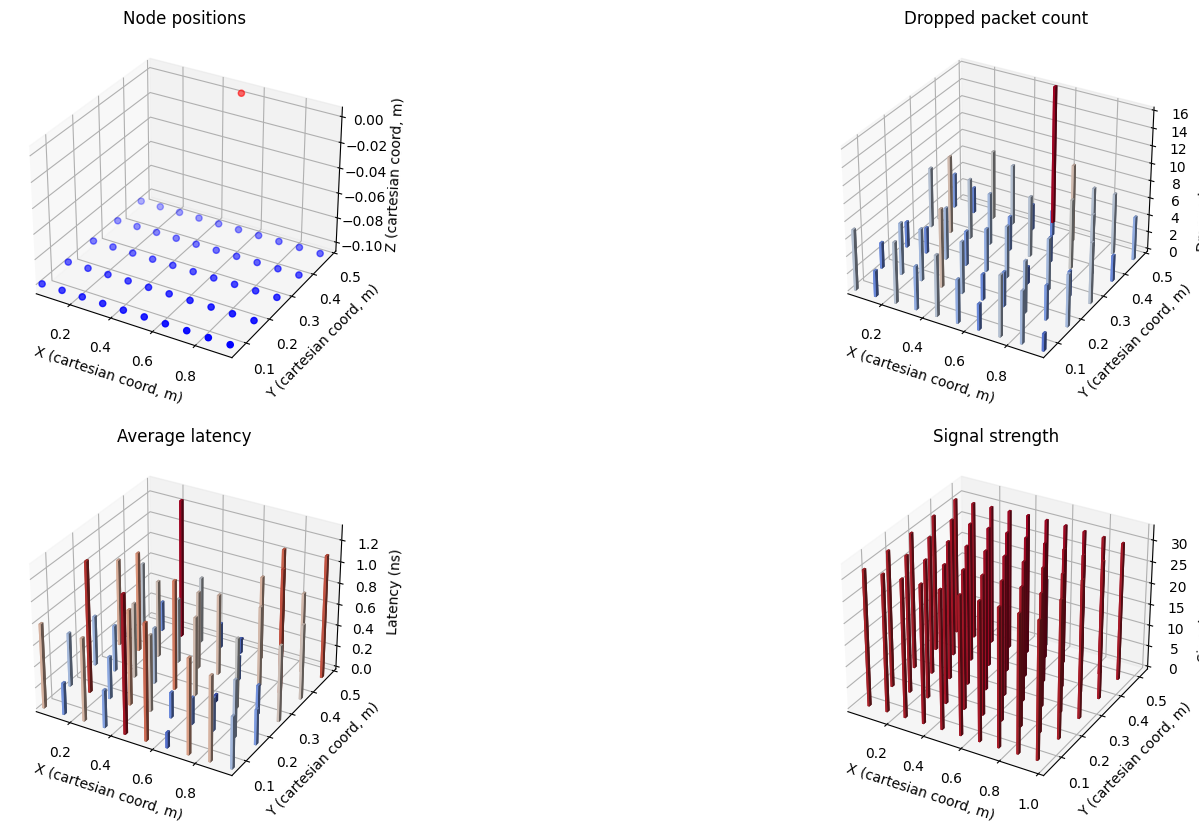

In [70]:
#matplotlib.use("TkAgg")
root = tkinter.Tk()

# Map 'Type' to colors
color_map = {'AP': 'red', 'STA': 'blue'}
colors = node_pos_df['NodeType'].map(color_map)

fig = plt.figure(dpi=100)

# Create four subplots
ax_node_pos = fig.add_subplot(221, projection='3d')
ax_dropped_packets = fig.add_subplot(222, projection='3d')
ax_latency = fig.add_subplot(223, projection='3d')
ax_signal = fig.add_subplot(224, projection='3d')

# Plot scatter on first subplot
ax_node_pos.scatter(node_pos_df['X'], node_pos_df['Y'], node_pos_df['Z'], c=colors)
ax_node_pos.set_title('Node positions')
ax_node_pos.set_xlabel('X (cartesian coord, m)')
ax_node_pos.set_ylabel('Y (cartesian coord, m)')
ax_node_pos.set_zlabel('Z (cartesian coord, m)')

# Plot bars on second subplot, where height is the dropped packet count
dropped_packets_colors = plt.cm.coolwarm(node_statistics_df['Dropped packet count'] / node_statistics_df['Dropped packet count'].max())
ax_dropped_packets.bar3d(node_statistics_df['X'], node_statistics_df['Y'], np.zeros(len(node_statistics_df)), .01, .01, node_statistics_df['Dropped packet count'], color=dropped_packets_colors)
ax_dropped_packets.set_title('Dropped packet count')
ax_dropped_packets.set_xlabel('X (cartesian coord, m)')
ax_dropped_packets.set_ylabel('Y (cartesian coord, m)')
ax_dropped_packets.set_zlabel('Dropped packet count')

# Plot bars on third subplot, where height is the average latency
latency_colors = plt.cm.coolwarm(node_statistics_df['Average latency'] / node_statistics_df['Average latency'].max())
ax_latency.bar3d(node_statistics_df['X'], node_statistics_df['Y'], np.zeros(len(node_statistics_df)), .01, .01, node_statistics_df['Average latency'], color=latency_colors)
ax_latency.set_title('Average latency')
ax_latency.set_xlabel('X (cartesian coord, m)')
ax_latency.set_ylabel('Y (cartesian coord, m)')
ax_latency.set_zlabel('Latency (ns)')

# Plot bars on fourth subplot, where height is the signal strength
signal_colors = plt.cm.coolwarm(node_statistics_df['Average signal strength'] / node_statistics_df['Average signal strength'].max())
ax_signal.bar3d(node_statistics_df['X'], node_statistics_df['Y'], np.zeros(len(node_statistics_df)), .01, .01, node_statistics_df['Average signal strength'], color=signal_colors)
ax_signal.set_title('Signal strength')
ax_signal.set_xlabel('X (cartesian coord, m)')
ax_signal.set_ylabel('Y (cartesian coord, m)')
ax_signal.set_zlabel('Signal strength (dB)')
# ax_signal.set_zlim(-100, -70)

# Sync the view limits
ax_node_pos.set_xlim(node_pos_df['X'].min(), node_pos_df['X'].max())
ax_node_pos.set_ylim(node_pos_df['Y'].min(), node_pos_df['Y'].max())
ax_dropped_packets.set_xlim(node_pos_df['X'].min(), node_pos_df['X'].max())
ax_dropped_packets.set_ylim(node_pos_df['Y'].min(), node_pos_df['Y'].max())
ax_latency.set_xlim(node_pos_df['X'].min(), node_pos_df['X'].max())
ax_latency.set_ylim(node_pos_df['Y'].min(), node_pos_df['Y'].max())

# Create canvas and toolbar
canvas = FigureCanvasTkAgg(fig, master=root)
canvas.draw()
toolbar = NavigationToolbar2Tk(canvas, root)
toolbar.update()
canvas.get_tk_widget().pack(side=tkinter.TOP, fill=tkinter.BOTH, expand=1)

# Function to sync rotation
def on_rotate(event):
    axes = [ax_node_pos, ax_dropped_packets, ax_latency, ax_signal]
    if event.inaxes in axes:
        # Get the current elevation and azimuth from the active axis
        elev = event.inaxes.elev
        azim = event.inaxes.azim
        
        # Update all other axes except the active one and unused one
        for ax in axes:
            if ax != event.inaxes:
                ax.view_init(elev=elev, azim=azim)
        
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('motion_notify_event', on_rotate)

tkinter.mainloop()